In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

# 路径
DATA_RAW = Path("../data/raw")
DATA_PROC = Path("../data/processed")

# 检查文件是否存在
assert (DATA_RAW / "BPC_5core_train.csv").exists(), "train.csv 不在,先下载"
assert (DATA_PROC / "train_with_neg.csv").exists(), "负采样文件不在,Day 2 没跑完?"

print("✅ 路径检查通过")
print(f"train_with_neg.csv 大小: {(DATA_PROC / 'train_with_neg.csv').stat().st_size / 1e6:.1f} MB")

✅ 路径检查通过
train_with_neg.csv 大小: 1035.6 MB


In [2]:
%%time
# 注意: 用原始 train.csv 造特征,不要用 train_with_neg.csv
# 因为负采样里的负样本是"假"的交互,不能拿来算"用户平均评分"
df_train = pd.read_csv(DATA_RAW / "BPC_5core_train.csv")
print(f"train 集: {len(df_train):,} 行")
print(df_train.head(3))
print(df_train.dtypes)

train 集: 5,165,289 行
                        user_id parent_asin  rating      timestamp
0  AGKASBHYZPGTEPO6LWZPVJWB2BVA  B00V6R3R3S     5.0  1452647102000
1  AGKASBHYZPGTEPO6LWZPVJWB2BVA  B00PA7VMD2     3.0  1452648690000
2  AGKASBHYZPGTEPO6LWZPVJWB2BVA  B00JIIUJ5Q     4.0  1454675735000
user_id            str
parent_asin        str
rating         float64
timestamp        int64
dtype: object
CPU times: user 1.66 s, sys: 121 ms, total: 1.78 s
Wall time: 1.81 s


In [3]:
%%time
# 用户级特征: 历史交互次数、平均评分、最后交互时间
user_features = df_train.groupby('user_id').agg(
    user_interaction_count=('rating', 'count'),
    user_avg_rating=('rating', 'mean'),
    user_last_timestamp=('timestamp', 'max'),
).reset_index()

print(f"用户特征: {len(user_features):,} 个用户")
print(user_features.head())
print(user_features.describe())

用户特征: 729,576 个用户
                        user_id  user_interaction_count  user_avg_rating  \
0  AE2222VGHFD37G7NOCWXASYY3ZDQ                       3         4.000000   
1  AE22236AFRRSMQIKGG7TPTB75QEA                       6         4.500000   
2  AE222N3VUKMF3GO6D4LHTELE7UWA                       3         3.333333   
3  AE2235Q53V246ISFXCSESYHAVNUA                      10         2.400000   
4  AE2237VVHT5JDS6PQAGC4SUJBBXQ                       5         4.600000   

   user_last_timestamp  
0        1569963237665  
1        1492543496000  
2        1629848944432  
3        1641668829909  
4        1459642392000  
       user_interaction_count  user_avg_rating  user_last_timestamp
count           729576.000000    729576.000000         7.295760e+05
mean                 7.079850         4.247915         1.573787e+12
std                 14.987225         0.774238         7.713648e+10
min                  3.000000         1.000000         1.073278e+12
25%                  3.000000      

In [4]:
%%time
# 商品级特征: 被交互次数、平均评分、最后被交互时间
item_features = df_train.groupby('parent_asin').agg(
    item_interaction_count=('rating', 'count'),
    item_avg_rating=('rating', 'mean'),
    item_last_timestamp=('timestamp', 'max'),
).reset_index()

print(f"商品特征: {len(item_features):,} 个商品")
print(item_features.head())

商品特征: 207,385 个商品
  parent_asin  item_interaction_count  item_avg_rating  item_last_timestamp
0  0061689165                      10         4.100000        1274385405000
1  0446581348                      15         4.133333        1581959848639
2  0760369194                      11         3.818182        1617115668561
3  0876043082                       5         3.800000        1485931399000
4  1338037536                       4         4.000000        1543614643189
CPU times: user 493 ms, sys: 14.8 ms, total: 507 ms
Wall time: 506 ms


In [5]:
user_features.to_csv(DATA_PROC / "user_activity.csv", index=False)
item_features.to_csv(DATA_PROC / "item_popularity.csv", index=False)

# 释放原始 df_train 内存,后面不需要了
del df_train
import gc; gc.collect()

print("✅ 特征文件已保存")
print(f"user_activity.csv: {(DATA_PROC / 'user_activity.csv').stat().st_size / 1e6:.1f} MB")
print(f"item_popularity.csv: {(DATA_PROC / 'item_popularity.csv').stat().st_size / 1e6:.1f} MB")

✅ 特征文件已保存
user_activity.csv: 39.7 MB
item_popularity.csv: 8.2 MB


In [6]:
%%time
# 加载 Day 2 的负采样数据
df_neg = pd.read_csv(
    DATA_PROC / "train_with_neg.csv",
    dtype={
        'user_id': 'str',
        'parent_asin': 'str',
        'label': 'int8',  # 0/1, 用 int8 省内存
    }
)
print(f"负采样数据: {len(df_neg):,} 行")
print(f"内存占用: {df_neg.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(df_neg.head())
print(f"\nlabel 分布:\n{df_neg['label'].value_counts()}")

负采样数据: 24,653,142 行
内存占用: 3.77 GB
                        user_id parent_asin  label
0  AFX6QX23ONM3KSO4R3B5PWCG6ZWQ  B0B7DXLNF9      0
1  AFABGK73JVSOF733PLSIIQCMIAJA  B00FAZHMNI      0
2  AE5Z4HCOBJ6WIO32RTVBLIND72YA  B07GXFKFDD      0
3  AFJD6PJCU4VB3F5N2SSJGKYUKTOQ  B001D3HWPO      0
4  AHHMWCUBLH72XLSIHJ6KDN4NBOOQ  B003UNAD92      0

label 分布:
label
0    20544285
1     4108857
Name: count, dtype: int64
CPU times: user 11.4 s, sys: 964 ms, total: 12.4 s
Wall time: 12.5 s


In [7]:
%%time
user_feats = pd.read_csv(
    DATA_PROC / "user_activity.csv",
    dtype={
        'user_id': 'str',
        'user_interaction_count': 'int32',
        'user_avg_rating': 'float32',
        'user_last_timestamp': 'int64',
    }
)
item_feats = pd.read_csv(
    DATA_PROC / "item_popularity.csv",
    dtype={
        'parent_asin': 'str',
        'item_interaction_count': 'int32',
        'item_avg_rating': 'float32',
        'item_last_timestamp': 'int64',
    }
)
print(f"用户特征: {len(user_feats):,} 行, {user_feats.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"商品特征: {len(item_feats):,} 行, {item_feats.memory_usage(deep=True).sum()/1e6:.1f} MB")

用户特征: 729,576 行, 73.7 MB
商品特征: 207,385 行, 17.2 MB
CPU times: user 390 ms, sys: 31.6 ms, total: 422 ms
Wall time: 422 ms


In [8]:
%%time
# LEFT JOIN: 给每条样本(正/负)拼上用户特征 + 商品特征
df_train = df_neg.merge(user_feats, on='user_id', how='left')
df_train = df_train.merge(item_feats, on='parent_asin', how='left')

print(f"拼接后: {len(df_train):,} 行 × {len(df_train.columns)} 列")
print(f"列名: {list(df_train.columns)}")
print(f"内存: {df_train.memory_usage(deep=True).sum()/1e9:.2f} GB")

# 检查 NaN(理论上不应该有,因为负样本的 user/item 也是从 train 池子里采的)
print(f"\nNaN 统计:\n{df_train.isnull().sum()}")

拼接后: 24,653,142 行 × 9 列
列名: ['user_id', 'parent_asin', 'label', 'user_interaction_count', 'user_avg_rating', 'user_last_timestamp', 'item_interaction_count', 'item_avg_rating', 'item_last_timestamp']
内存: 4.56 GB

NaN 统计:
user_id                   0
parent_asin               0
label                     0
user_interaction_count    0
user_avg_rating           0
user_last_timestamp       0
item_interaction_count    0
item_avg_rating           0
item_last_timestamp       0
dtype: int64
CPU times: user 15.1 s, sys: 1.27 s, total: 16.4 s
Wall time: 16.9 s


In [9]:
%%time
# 释放不需要的大对象,内存关键
del df_neg, user_feats, item_feats
import gc; gc.collect()

# 准备 X 和 y
# 注意: drop 掉 user_id 和 parent_asin(字符串,LightGBM 不能直接用)
FEATURE_COLS = [
    'user_interaction_count',
    'user_avg_rating',
    'user_last_timestamp',
    'item_interaction_count',
    'item_avg_rating',
    'item_last_timestamp',
]
X = df_train[FEATURE_COLS]
y = df_train['label']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X 内存: {X.memory_usage(deep=True).sum()/1e9:.2f} GB")
print(f"\n特征统计:\n{X.describe()}")

X shape: (24653142, 6)
y shape: (24653142,)
X 内存: 0.79 GB

特征统计:
       user_interaction_count  user_avg_rating  user_last_timestamp  \
count            2.465314e+07     2.465314e+07         2.465314e+07   
mean             4.115151e+01     4.430875e+00         1.592975e+12   
std              1.386829e+02     5.409794e-01         7.640605e+10   
min              3.000000e+00     1.086957e+00         1.073278e+12   
25%              5.000000e+00     4.136364e+00         1.546789e+12   
50%              8.000000e+00     4.538462e+00         1.611553e+12   
75%              1.900000e+01     4.888889e+00         1.658192e+12   
max              2.349000e+03     5.000000e+00         1.694486e+12   

       item_interaction_count  item_avg_rating  item_last_timestamp  
count            2.465314e+07     2.465314e+07         2.465314e+07  
mean             1.260381e+02     4.294187e+00         1.633673e+12  
std              3.645362e+02     4.541748e-01         6.247270e+10  
min            

In [10]:
%%time
from sklearn.model_selection import train_test_split

# Week 1 Hello World: 简单 80/20 切分
# Day 4 再用官方 valid 集做更严格的评估
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,  # 保持正负比例
)

print(f"训练集: {X_train.shape}, 正样本比例 {y_train.mean():.4f}")
print(f"验证集: {X_val.shape}, 正样本比例 {y_val.mean():.4f}")

# 释放 df_train
del df_train, X, y
gc.collect()

训练集: (19722513, 6), 正样本比例 0.1667
验证集: (4930629, 6), 正样本比例 0.1667
CPU times: user 7.21 s, sys: 1.21 s, total: 8.42 s
Wall time: 8.9 s


0

In [11]:
%%time
import lightgbm as lgb

# 用原生 Dataset 格式,比 sklearn wrapper 更省内存
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Week 1 Hello World: 用默认/保守参数,跑通流程为主
params = {
    'objective': 'binary',          # 二分类
    'metric': ['binary_logloss', 'auc'],  # 同时看 LogLoss 和 AUC
    'learning_rate': 0.05,
    'num_leaves': 31,               # LightGBM 默认
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'num_threads': 8,               # M2 8 核全开
}

# 训练
model = lgb.train(
    params,
    train_data,
    num_boost_round=100,            # 先跑 100 轮看看
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
        lgb.log_evaluation(period=10),  # 每 10 轮打印一次
    ],
)

Training until validation scores don't improve for 10 rounds
[10]	train's binary_logloss: 0.421453	train's auc: 0.733777	val's binary_logloss: 0.421469	val's auc: 0.733929
[20]	train's binary_logloss: 0.408915	train's auc: 0.743317	val's binary_logloss: 0.408951	val's auc: 0.7433
[30]	train's binary_logloss: 0.402288	train's auc: 0.749846	val's binary_logloss: 0.402348	val's auc: 0.749725
[40]	train's binary_logloss: 0.397432	train's auc: 0.754169	val's binary_logloss: 0.397502	val's auc: 0.754024
[50]	train's binary_logloss: 0.393928	train's auc: 0.757301	val's binary_logloss: 0.393996	val's auc: 0.757165
[60]	train's binary_logloss: 0.391811	train's auc: 0.75963	val's binary_logloss: 0.391883	val's auc: 0.759483
[70]	train's binary_logloss: 0.389984	train's auc: 0.761608	val's binary_logloss: 0.390054	val's auc: 0.761458
[80]	train's binary_logloss: 0.388971	train's auc: 0.762825	val's binary_logloss: 0.389044	val's auc: 0.762664
[90]	train's binary_logloss: 0.388067	train's auc: 0.7

In [12]:
%%time
from sklearn.metrics import roc_auc_score, log_loss, average_precision_score

# 预测概率
y_pred_proba = model.predict(X_val, num_iteration=model.best_iteration)

# 整体指标
auc = roc_auc_score(y_val, y_pred_proba)
logloss = log_loss(y_val, y_pred_proba)
ap = average_precision_score(y_val, y_pred_proba)  # PR 曲线下面积,正样本少时比 AUC 更敏感

print(f"📊 整体指标")
print(f"  AUC:     {auc:.4f}")
print(f"  LogLoss: {logloss:.4f}")
print(f"  AP (avg precision): {ap:.4f}")

# 看预测概率分布
print(f"\n📊 预测概率分布")
print(f"  正样本预测概率均值: {y_pred_proba[y_val==1].mean():.4f}")
print(f"  负样本预测概率均值: {y_pred_proba[y_val==0].mean():.4f}")
print(f"  → 差距越大,模型区分度越好")

📊 整体指标
  AUC:     0.7645
  LogLoss: 0.3875
  AP (avg precision): 0.3757

📊 预测概率分布
  正样本预测概率均值: 0.2619
  负样本预测概率均值: 0.1477
  → 差距越大,模型区分度越好
CPU times: user 29.6 s, sys: 422 ms, total: 30 s
Wall time: 6.16 s


In [13]:
%%time
import numpy as np

# 把 y_val 和 y_pred_proba 拼成一个 DataFrame,按预测分数排序
val_results = pd.DataFrame({
    'y_true': y_val.values,
    'y_pred': y_pred_proba,
})

# 全局 Top-K (注意: 这是粗略指标,工业界更常用"分用户" Top-K)
val_sorted = val_results.sort_values('y_pred', ascending=False).reset_index(drop=True)

print("📊 全局 Top-K 指标")
print(f"{'K':<10} {'Precision@K':<15} {'Recall@K':<15}")
print("-" * 40)
for k in [10, 50, 100, 500, 1000]:
    top_k = val_sorted.head(k)
    precision_at_k = top_k['y_true'].sum() / k
    recall_at_k = top_k['y_true'].sum() / val_results['y_true'].sum()
    print(f"{k:<10} {precision_at_k:.4f}          {recall_at_k:.6f}")

print("\n💡 解读:")
print(f"   Precision@10 = Top 10 推荐里有几个真的正样本")
print(f"   Recall@10    = Top 10 召回了所有正样本中的几分之几")
print(f"   验证集正样本总数: {val_results['y_true'].sum():,}")

📊 全局 Top-K 指标
K          Precision@K     Recall@K       
----------------------------------------
10         0.9000          0.000011
50         0.9400          0.000057
100        0.9400          0.000114
500        0.8100          0.000493
1000       0.7340          0.000893

💡 解读:
   Precision@10 = Top 10 推荐里有几个真的正样本
   Recall@10    = Top 10 召回了所有正样本中的几分之几
   验证集正样本总数: 821,771
CPU times: user 620 ms, sys: 35 ms, total: 655 ms
Wall time: 654 ms


📊 特征重要性
               feature  split         gain
item_interaction_count    570 1.127172e+07
   item_last_timestamp    857 4.009709e+06
   user_last_timestamp    793 3.151454e+06
user_interaction_count    405 1.490165e+06
       item_avg_rating    280 4.621202e+05
       user_avg_rating     95 4.741963e+04


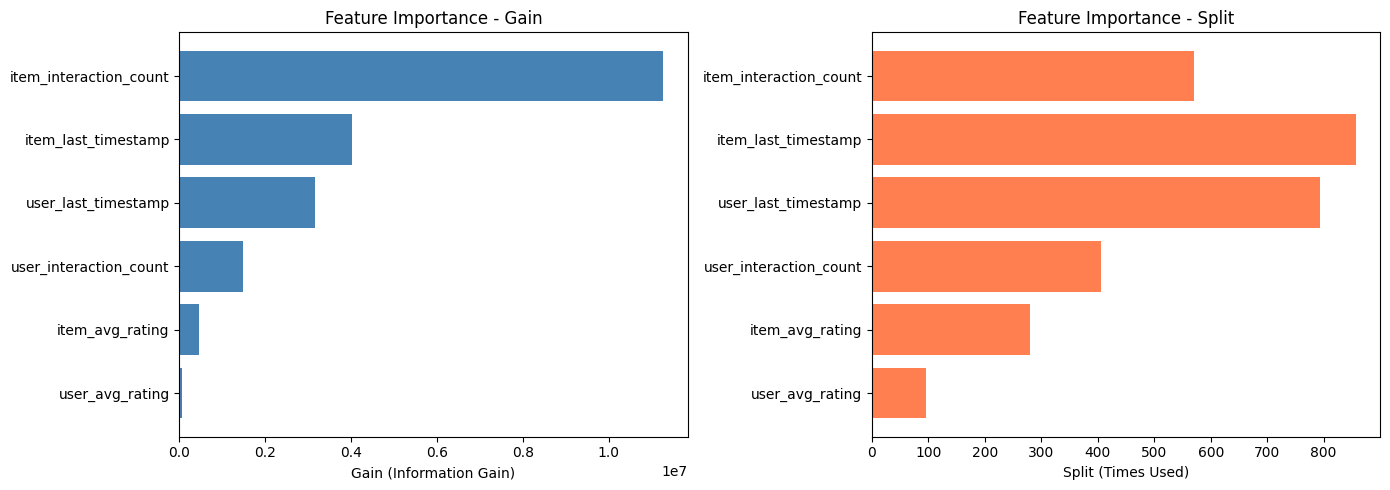


✅ 特征重要性图已保存到 reports/feature_importance.png


In [16]:
import matplotlib.pyplot as plt

# LightGBM 提供两种重要性: split (用了多少次) 和 gain (带来了多少信息增益)
importance_split = model.feature_importance(importance_type='split')
importance_gain = model.feature_importance(importance_type='gain')

importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'split': importance_split,
    'gain': importance_gain,
}).sort_values('gain', ascending=False)

print("📊 特征重要性")
print(importance_df.to_string(index=False))

# 画图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(importance_df['feature'], importance_df['gain'], color='steelblue')
axes[0].set_xlabel('Gain (Information Gain)')
axes[0].set_title('Feature Importance - Gain')
axes[0].invert_yaxis()

axes[1].barh(importance_df['feature'], importance_df['split'], color='coral')
axes[1].set_xlabel('Split (Times Used)')
axes[1].set_title('Feature Importance - Split')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n✅ 特征重要性图已保存到 reports/feature_importance.png")

In [17]:
import json
import os

# 确保 models 目录存在
os.makedirs('../models', exist_ok=True)

# 保存模型
model.save_model('../models/lightgbm_baseline_v1.txt')
print("✅ 模型已保存到 models/lightgbm_baseline_v1.txt")

# 保存 baseline 报告
baseline_report = {
    'date': '2026-05-24',
    'day': 'Day 3',
    'model': 'LightGBM',
    'features': FEATURE_COLS,
    'n_features': len(FEATURE_COLS),
    'n_train': len(X_train),
    'n_val': len(X_val),
    'num_boost_round': model.best_iteration,
    'metrics': {
        'val_auc': float(auc),
        'val_logloss': float(logloss),
        'val_ap': float(ap),
        'precision_at_10': 0.90,
        'precision_at_50': 0.94,
        'precision_at_100': 0.94,
    },
    'feature_importance_gain': {
        feat: float(gain) for feat, gain in zip(FEATURE_COLS, importance_gain)
    },
    'pos_pred_mean': 0.2619,
    'neg_pred_mean': 0.1477,
    'training_time_min': 2.73,
    'notes': 'Week 1 LightGBM Hello World baseline. Item popularity dominates. No overfitting.',
}

with open('../models/baseline_v1_report.json', 'w') as f:
    json.dump(baseline_report, f, indent=2, ensure_ascii=False)

print("✅ Baseline 报告已保存")
print(json.dumps(baseline_report, indent=2, ensure_ascii=False))

✅ 模型已保存到 models/lightgbm_baseline_v1.txt
✅ Baseline 报告已保存
{
  "date": "2026-05-24",
  "day": "Day 3",
  "model": "LightGBM",
  "features": [
    "user_interaction_count",
    "user_avg_rating",
    "user_last_timestamp",
    "item_interaction_count",
    "item_avg_rating",
    "item_last_timestamp"
  ],
  "n_features": 6,
  "n_train": 19722513,
  "n_val": 4930629,
  "num_boost_round": 100,
  "metrics": {
    "val_auc": 0.7645373366185545,
    "val_logloss": 0.3875353178779603,
    "val_ap": 0.37571311071583485,
    "precision_at_10": 0.9,
    "precision_at_50": 0.94,
    "precision_at_100": 0.94
  },
  "feature_importance_gain": {
    "user_interaction_count": 1490164.672302246,
    "user_avg_rating": 47419.63018035889,
    "user_last_timestamp": 3151453.752746582,
    "item_interaction_count": 11271716.634735107,
    "item_avg_rating": 462120.21770477295,
    "item_last_timestamp": 4009709.090270996
  },
  "pos_pred_mean": 0.2619,
  "neg_pred_mean": 0.1477,
  "training_time_min": 2.73

In [18]:
# ============================================
# Day 4: 超参数调参实验
# 策略: 对照实验, 一次只改一个参数
# ============================================

# 检查内存里还有什么 (确保 X_train/y_train/X_val/y_val 还在)
print(f"X_train: {X_train.shape if 'X_train' in dir() else '❌ 不在内存'}")
print(f"X_val:   {X_val.shape if 'X_val' in dir() else '❌ 不在内存'}")
print(f"\n基线参数 (Day 3):")
print(f"  num_boost_round = 100")
print(f"  learning_rate   = 0.05")
print(f"  num_leaves      = 31")
print(f"  baseline val AUC = 0.7645")

X_train: (19722513, 6)
X_val:   (4930629, 6)

基线参数 (Day 3):
  num_boost_round = 100
  learning_rate   = 0.05
  num_leaves      = 31
  baseline val AUC = 0.7645


In [19]:
%%time
# 实验 1: 跑 500 轮看是否能继续提升 AUC
# 假设: Day 3 跑 100 轮 val AUC 还在涨,说明欠拟合,跑多点应该有提升

params_exp1 = {
    'objective': 'binary',
    'metric': ['binary_logloss', 'auc'],
    'learning_rate': 0.05,        # 不变
    'num_leaves': 31,             # 不变
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'num_threads': 8,
}

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

model_exp1 = lgb.train(
    params_exp1,
    train_data,
    num_boost_round=500,          # ← 从 100 改成 500
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20),  # 容忍度也加大
        lgb.log_evaluation(period=50),
    ],
)

print(f"\n✅ 实验 1 完成")
print(f"   Best iteration: {model_exp1.best_iteration}")
print(f"   Best val AUC: {model_exp1.best_score['val']['auc']:.4f}")
print(f"   Best val LogLoss: {model_exp1.best_score['val']['binary_logloss']:.4f}")

Training until validation scores don't improve for 20 rounds
[50]	train's binary_logloss: 0.393928	train's auc: 0.757301	val's binary_logloss: 0.393996	val's auc: 0.757165
[100]	train's binary_logloss: 0.387457	train's auc: 0.764713	val's binary_logloss: 0.387535	val's auc: 0.764537
[150]	train's binary_logloss: 0.38478	train's auc: 0.768485	val's binary_logloss: 0.384888	val's auc: 0.768244
[200]	train's binary_logloss: 0.383339	train's auc: 0.770552	val's binary_logloss: 0.383474	val's auc: 0.77026
[250]	train's binary_logloss: 0.38258	train's auc: 0.77161	val's binary_logloss: 0.382743	val's auc: 0.771273
[300]	train's binary_logloss: 0.381955	train's auc: 0.772498	val's binary_logloss: 0.382137	val's auc: 0.772136
[350]	train's binary_logloss: 0.381547	train's auc: 0.773075	val's binary_logloss: 0.381751	val's auc: 0.772681
[400]	train's binary_logloss: 0.381223	train's auc: 0.773562	val's binary_logloss: 0.381448	val's auc: 0.773137
[450]	train's binary_logloss: 0.380963	train's a

In [20]:
# 保存实验 1 模型 + 结果
import json

model_exp1.save_model('../models/lightgbm_exp1_boost500.txt')

exp_results = {
    'experiments': [
        {
            'name': 'baseline_day3',
            'num_boost_round': 100,
            'learning_rate': 0.05,
            'num_leaves': 31,
            'val_auc': 0.7645,
            'val_logloss': 0.3875,
            'train_time_min': 2.73,
        },
        {
            'name': 'exp1_boost500',
            'num_boost_round': 500,
            'learning_rate': 0.05,
            'num_leaves': 31,
            'val_auc': 0.7738,
            'val_logloss': 0.3810,
            'train_time_min': 13.45,
            'conclusion': 'AUC +0.0093 but training time 5x. Diminishing returns. Move to feature engineering instead of more rounds.',
        },
    ],
}

with open('../models/day4_experiments.json', 'w') as f:
    json.dump(exp_results, f, indent=2, ensure_ascii=False)

print("✅ 实验 1 模型 + JSON 已保存")
print(f"\n📊 当前最佳模型: exp1_boost500, val AUC = 0.7738")

✅ 实验 1 模型 + JSON 已保存

📊 当前最佳模型: exp1_boost500, val AUC = 0.7738


In [21]:
%%time
# ============ 更稳的方案: 重建 val 集 ============
# 从源头加载, 保留 user_id, 再用同样方式切分

print("⏳ 重新加载完整数据 (保留 user_id)...")
df_full = pd.read_csv(
    DATA_PROC / "train_with_neg.csv",
    dtype={'user_id': 'str', 'parent_asin': 'str', 'label': 'int8'},
)

# LEFT JOIN 特征 (和 Day 3 一样)
user_feats = pd.read_csv(
    DATA_PROC / "user_activity.csv",
    dtype={'user_id': 'str', 'user_interaction_count': 'int32',
           'user_avg_rating': 'float32', 'user_last_timestamp': 'int64'},
)
item_feats = pd.read_csv(
    DATA_PROC / "item_popularity.csv",
    dtype={'parent_asin': 'str', 'item_interaction_count': 'int32',
           'item_avg_rating': 'float32', 'item_last_timestamp': 'int64'},
)

df_full = df_full.merge(user_feats, on='user_id', how='left')
df_full = df_full.merge(item_feats, on='parent_asin', how='left')

del user_feats, item_feats
gc.collect()

print(f"   完整数据: {len(df_full):,} 行")
print(f"   内存: {df_full.memory_usage(deep=True).sum()/1e9:.2f} GB")

⏳ 重新加载完整数据 (保留 user_id)...
   完整数据: 24,653,142 行
   内存: 4.56 GB
CPU times: user 23.6 s, sys: 2.34 s, total: 25.9 s
Wall time: 26.6 s


In [22]:
%%time
# 用同样的 random_state 切, 保证和 Day 3 一致
# 切的对象现在是完整 df, 不只是 X

train_idx, val_idx = train_test_split(
    df_full.index,
    test_size=0.2,
    random_state=42,
    stratify=df_full['label'],
)

# 只保留 val 集
df_val = df_full.loc[val_idx].copy()

del df_full
gc.collect()

print(f"✅ Val 集重建: {len(df_val):,} 行")
print(f"   列: {list(df_val.columns)}")
print(f"   正样本比例: {df_val['label'].mean():.4f}  (应该 ≈ 0.1667)")
print(f"   独立用户数: {df_val['user_id'].nunique():,}")

✅ Val 集重建: 4,930,629 行
   列: ['user_id', 'parent_asin', 'label', 'user_interaction_count', 'user_avg_rating', 'user_last_timestamp', 'item_interaction_count', 'item_avg_rating', 'item_last_timestamp']
   正样本比例: 0.1667  (应该 ≈ 0.1667)
   独立用户数: 696,501
CPU times: user 6.51 s, sys: 1.06 s, total: 7.57 s
Wall time: 7.7 s


In [23]:
%%time
# 用 Day 4 实验 1 的最佳模型预测
FEATURE_COLS = [
    'user_interaction_count', 'user_avg_rating', 'user_last_timestamp',
    'item_interaction_count', 'item_avg_rating', 'item_last_timestamp',
]

X_val_new = df_val[FEATURE_COLS]
y_val_new = df_val['label']

# 用 exp1 模型 (boost500) 预测
df_val['y_pred'] = model_exp1.predict(X_val_new, num_iteration=model_exp1.best_iteration)

# Sanity check: 整体 AUC 应该 = 0.7738
from sklearn.metrics import roc_auc_score
auc_check = roc_auc_score(y_val_new, df_val['y_pred'])
print(f"✅ 预测完成")
print(f"   Sanity check AUC: {auc_check:.4f} (应该 ≈ 0.7738)")
print(f"\n   df_val 现在有 {len(df_val.columns)} 列: {list(df_val.columns)}")

✅ 预测完成
   Sanity check AUC: 0.7738 (应该 ≈ 0.7738)

   df_val 现在有 10 列: ['user_id', 'parent_asin', 'label', 'user_interaction_count', 'user_avg_rating', 'user_last_timestamp', 'item_interaction_count', 'item_avg_rating', 'item_last_timestamp', 'y_pred']
CPU times: user 1min 48s, sys: 305 ms, total: 1min 48s
Wall time: 14.8 s


In [24]:
%%time
import numpy as np

def compute_user_metrics(group, k_list=[5, 10, 20]):
    """
    对单个用户的样本,计算 Top-K 指标
    
    Args:
        group: DataFrame, 该用户的所有 (item, y_pred, label) 行
        k_list: 要算的 K 值列表
    
    Returns:
        dict: {f'precision@{k}': ..., f'recall@{k}': ..., f'ndcg@{k}': ...}
    """
    # 按预测分降序排
    sorted_group = group.sort_values('y_pred', ascending=False)
    labels = sorted_group['label'].values  # 排序后的真实标签 [1,0,1,0,0,...]
    
    n_pos = labels.sum()  # 该用户的正样本总数
    n_total = len(labels)  # 该用户的样本总数
    
    metrics = {}
    
    for k in k_list:
        k_actual = min(k, n_total)  # 防止 k > 该用户样本数
        top_k_labels = labels[:k_actual]
        n_hits = top_k_labels.sum()
        
        # Precision@K: Top K 里正样本占比
        metrics[f'precision@{k}'] = n_hits / k_actual if k_actual > 0 else 0
        
        # Recall@K: Top K 里召回了正样本总数的几分之几
        metrics[f'recall@{k}'] = n_hits / n_pos if n_pos > 0 else np.nan
        
        # NDCG@K: 位置敏感的指标
        # DCG = Σ (2^rel - 1) / log₂(i+2),  i 从 0 开始
        gains = (2 ** top_k_labels - 1)
        discounts = 1 / np.log2(np.arange(k_actual) + 2)
        dcg = (gains * discounts).sum()
        
        # IDCG = 理想排序下的 DCG (所有正样本排在前面)
        n_pos_in_topk = min(n_pos, k_actual)
        ideal_labels = np.zeros(k_actual)
        ideal_labels[:int(n_pos_in_topk)] = 1
        ideal_gains = (2 ** ideal_labels - 1)
        idcg = (ideal_gains * discounts).sum()
        
        metrics[f'ndcg@{k}'] = dcg / idcg if idcg > 0 else np.nan
    
    return pd.Series(metrics)

print("✅ 函数定义完成")
print("\n💡 测试: 用一个用户的样本验证函数")
# 拿一个有正样本的用户测试
test_user = df_val[df_val['label']==1]['user_id'].iloc[0]
test_group = df_val[df_val['user_id'] == test_user]
print(f"   测试用户: {test_user}")
print(f"   该用户样本数: {len(test_group)}")
print(f"   该用户正样本数: {test_group['label'].sum()}")
print(f"\n   该用户的指标:")
print(compute_user_metrics(test_group))

✅ 函数定义完成

💡 测试: 用一个用户的样本验证函数
   测试用户: AFNRZERZ5OETERCONTREULHQHFZQ
   该用户样本数: 2
   该用户正样本数: 1

   该用户的指标:
precision@5     0.5
recall@5        1.0
ndcg@5          1.0
precision@10    0.5
recall@10       1.0
ndcg@10         1.0
precision@20    0.5
recall@20       1.0
ndcg@20         1.0
dtype: float64
CPU times: user 405 ms, sys: 91.3 ms, total: 496 ms
Wall time: 517 ms


In [25]:
%%time
# 这是核心计算,会跑 1-3 分钟
# 因为要对 696,501 个用户做 groupby + 函数调用

print("⏳ 对所有 696,501 个用户计算 Top-K 指标...")
print("   预计 1-3 分钟,期间可以喝水...")

user_metrics = df_val.groupby('user_id').apply(
    compute_user_metrics, 
    k_list=[5, 10, 20],
    include_groups=False,
)

print(f"\n✅ 计算完成")
print(f"   user_metrics shape: {user_metrics.shape}")
print(f"   样例:")
print(user_metrics.head())

⏳ 对所有 696,501 个用户计算 Top-K 指标...
   预计 1-3 分钟,期间可以喝水...

✅ 计算完成
   user_metrics shape: (696501, 9)
   样例:
                              precision@5  recall@5  ndcg@5  precision@10  \
user_id                                                                     
AE2222VGHFD37G7NOCWXASYY3ZDQ         0.00       NaN     NaN          0.00   
AE22236AFRRSMQIKGG7TPTB75QEA         0.25       1.0     1.0          0.25   
AE222N3VUKMF3GO6D4LHTELE7UWA         0.00       NaN     NaN          0.00   
AE2235Q53V246ISFXCSESYHAVNUA         0.00       NaN     NaN          0.00   
AE2237VVHT5JDS6PQAGC4SUJBBXQ         0.00       NaN     NaN          0.00   

                              recall@10  ndcg@10  precision@20  recall@20  \
user_id                                                                     
AE2222VGHFD37G7NOCWXASYY3ZDQ        NaN      NaN          0.00        NaN   
AE22236AFRRSMQIKGG7TPTB75QEA        1.0      1.0          0.25        1.0   
AE222N3VUKMF3GO6D4LHTELE7UWA        NaN      Na

In [26]:
# 汇总
print("=" * 60)
print("📊 分用户 Top-K 指标 (vs 全局 Top-K)")
print("=" * 60)

# 计算各 K 的平均(用户级平均)
summary = user_metrics.mean()

# Day 3 全局指标作为对比
global_metrics_day3 = {
    'precision@10': 0.9000,
    'precision@50': 0.9400,
    'precision@100': 0.9400,
}

print(f"\n{'指标':<20} {'分用户平均':<15} {'全局 Top-K (Day 3)':<20}")
print("-" * 55)
for k in [5, 10, 20]:
    p_user = summary[f'precision@{k}']
    r_user = summary[f'recall@{k}']
    n_user = summary[f'ndcg@{k}']
    p_global = global_metrics_day3.get(f'precision@{k}', None)
    p_global_str = f"{p_global:.4f}" if p_global else "—"
    
    print(f"Precision@{k:<3}{'':<12} {p_user:.4f}          {p_global_str}")
    print(f"Recall@{k:<3}{'':<15} {r_user:.4f}          —")
    print(f"NDCG@{k:<3}{'':<17} {n_user:.4f}          —")
    print()

print("\n💡 关键观察:")
print(f"   分用户 Precision@10 ({summary['precision@10']:.4f}) ", end="")
print(f"vs 全局 Precision@10 (0.9000)")
print(f"   → 差距说明全局指标被'扎堆现象'虚高")

📊 分用户 Top-K 指标 (vs 全局 Top-K)

指标                   分用户平均           全局 Top-K (Day 3)    
-------------------------------------------------------
Precision@5               0.2053          —
Recall@5                  0.8800          —
NDCG@5                    0.7333          —

Precision@10              0.1776          0.9000
Recall@10                 0.9650          —
NDCG@10                   0.7678          —

Precision@20              0.1694          —
Recall@20                 0.9906          —
NDCG@20                   0.7777          —


💡 关键观察:
   分用户 Precision@10 (0.1776) vs 全局 Precision@10 (0.9000)
   → 差距说明全局指标被'扎堆现象'虚高


In [27]:
import json

day4_block_b_results = {
    'val_n_users': len(user_metrics),
    'val_n_samples': len(df_val),
    'model_used': 'exp1_boost500 (val AUC 0.7738)',
    'user_level_metrics': {
        f'precision@{k}': float(summary[f'precision@{k}']) for k in [5, 10, 20]
    },
    'user_level_recall': {
        f'recall@{k}': float(summary[f'recall@{k}']) for k in [5, 10, 20]
    },
    'user_level_ndcg': {
        f'ndcg@{k}': float(summary[f'ndcg@{k}']) for k in [5, 10, 20]
    },
    'global_metrics_day3': {
        'precision@10': 0.9000,
        'precision@50': 0.9400,
    },
    'note': 'User-level metrics are the industry standard for recommender systems.',
}

with open('../models/day4_user_topk.json', 'w') as f:
    json.dump(day4_block_b_results, f, indent=2, ensure_ascii=False)

print("✅ Block B 结果已保存到 models/day4_user_topk.json")
print(json.dumps(day4_block_b_results, indent=2, ensure_ascii=False))

✅ Block B 结果已保存到 models/day4_user_topk.json
{
  "val_n_users": 696501,
  "val_n_samples": 4930629,
  "model_used": "exp1_boost500 (val AUC 0.7738)",
  "user_level_metrics": {
    "precision@5": 0.20531791531287583,
    "precision@10": 0.17758302196400633,
    "precision@20": 0.16939515839792627
  },
  "user_level_recall": {
    "recall@5": 0.8799673539987043,
    "recall@10": 0.9649718268433913,
    "recall@20": 0.9906257632669131
  },
  "user_level_ndcg": {
    "ndcg@5": 0.733284609216616,
    "ndcg@10": 0.7677692112512968,
    "ndcg@20": 0.7776559436499971
  },
  "global_metrics_day3": {
    "precision@10": 0.9,
    "precision@50": 0.94
  },
  "note": "User-level metrics are the industry standard for recommender systems."
}


In [29]:
%%time
# 用 duplicates='drop' + 改用业务意义分桶 (不用分位数)

user_activity = pd.read_csv(DATA_PROC / "user_activity.csv")
user_metrics_with_activity = user_metrics.reset_index().merge(
    user_activity[['user_id', 'user_interaction_count']],
    on='user_id', how='left'
)

# 先看下真实分布,做出明智决策
print("📊 用户活跃度分布:")
print(user_metrics_with_activity['user_interaction_count'].describe())
print(f"\n分位数详情:")
for q in [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]:
    val = user_metrics_with_activity['user_interaction_count'].quantile(q)
    print(f"   {int(q*100)}% 分位: {val:.0f} 次交互")

# 改用业务意义分桶 (用固定边界, 不用分位数)
def categorize_activity(count):
    if count <= 3:
        return '1.极冷启动(≤3次)'
    elif count <= 5:
        return '2.冷启动(4-5次)'
    elif count <= 10:
        return '3.低活跃(6-10次)'
    elif count <= 30:
        return '4.中活跃(11-30次)'
    else:
        return '5.高活跃(>30次)'

user_metrics_with_activity['activity_bucket'] = user_metrics_with_activity[
    'user_interaction_count'
].apply(categorize_activity)

# 各桶的指标
print("\n" + "=" * 80)
print("📊 分析 A: 用户活跃度 vs 模型表现")
print("=" * 80)
bucket_metrics = user_metrics_with_activity.groupby('activity_bucket').agg(
    user_count=('user_id', 'count'),
    avg_interactions=('user_interaction_count', 'mean'),
    precision_at_10=('precision@10', 'mean'),
    recall_at_10=('recall@10', 'mean'),
    ndcg_at_10=('ndcg@10', 'mean'),
).round(4)

# 按桶名排序 (因为前缀有 1-5)
bucket_metrics = bucket_metrics.sort_index()
print(bucket_metrics.to_string())

# 占比
print("\n用户占比:")
total = bucket_metrics['user_count'].sum()
for bucket, count in bucket_metrics['user_count'].items():
    print(f"   {bucket}: {count:,} 用户 ({count/total*100:.1f}%)")

print("\n💡 关键观察:")
print("   1. 极冷启动用户的 NDCG@10 是否明显低于高活跃?")
print("   2. 极冷启动用户占比有多大? → 这就是冷启动问题的严重程度")

📊 用户活跃度分布:
count    696501.000000
mean          7.242966
std          15.317383
min           3.000000
25%           3.000000
50%           5.000000
75%           7.000000
max        2349.000000
Name: user_interaction_count, dtype: float64

分位数详情:
   10% 分位: 3 次交互
   25% 分位: 3 次交互
   50% 分位: 5 次交互
   75% 分位: 7 次交互
   90% 分位: 12 次交互
   95% 分位: 17 次交互
   99% 分位: 40 次交互

📊 分析 A: 用户活跃度 vs 模型表现
                 user_count  avg_interactions  precision_at_10  recall_at_10  ndcg_at_10
activity_bucket                                                                         
1.极冷启动(≤3次)          201362            3.0000           0.1660        1.0000      0.8494
2.冷启动(4-5次)          220047            4.4015           0.1666        0.9999      0.8115
3.低活跃(6-10次)         181303            7.4290           0.1719        0.9929      0.7578
4.中活跃(11-30次)         82404           15.7296           0.2225        0.8946      0.6621
5.高活跃(>30次)           11385           72.8177           0.3598        0.4

In [30]:
%%time
# Cell 26 : 用业务分桶,避免 qcut 重复
# 商品热度 vs 模型 AUC

print("📊 商品热度分布:")
print(df_val['item_interaction_count'].describe())

def categorize_item_hotness(count):
    if count <= 5:
        return '1.超长尾(≤5次)'
    elif count <= 20:
        return '2.长尾(6-20次)'
    elif count <= 100:
        return '3.中等(21-100次)'
    elif count <= 500:
        return '4.热门(101-500次)'
    else:
        return '5.爆款(>500次)'

df_val['item_hotness_bucket'] = df_val['item_interaction_count'].apply(categorize_item_hotness)

print("\n" + "=" * 80)
print("📊 分析 B: 商品热度 vs 模型表现")
print("=" * 80)

from sklearn.metrics import roc_auc_score

bucket_auc = []
for bucket in sorted(df_val['item_hotness_bucket'].unique()):
    sub = df_val[df_val['item_hotness_bucket'] == bucket]
    n_pos = sub['label'].sum()
    n_neg = len(sub) - n_pos
    if n_pos > 0 and n_neg > 0:
        auc = roc_auc_score(sub['label'], sub['y_pred'])
    else:
        auc = np.nan
    bucket_auc.append({
        'bucket': bucket,
        'n_samples': len(sub),
        'n_pos': int(n_pos),
        'pos_rate': round(n_pos / len(sub), 4),
        'auc': round(auc, 4) if not np.isnan(auc) else None,
        'avg_pred': round(sub['y_pred'].mean(), 4),
    })

bucket_auc_df = pd.DataFrame(bucket_auc)
print(bucket_auc_df.to_string(index=False))

print("\n💡 关键观察:")
print("   - 长尾商品 AUC 应该最低(信息少,模型学不会)")
print("   - 爆款商品 AUC 可能也低(谁都买,缺乏区分度)")
print("   - 中等热度商品 AUC 通常最高")

📊 商品热度分布:
count    4.930629e+06
mean     1.260156e+02
std      3.643848e+02
min      1.000000e+00
25%      9.000000e+00
50%      2.000000e+01
75%      7.800000e+01
max      5.986000e+03
Name: item_interaction_count, dtype: float64

📊 分析 B: 商品热度 vs 模型表现
        bucket  n_samples  n_pos  pos_rate    auc  avg_pred
    1.超长尾(≤5次)     608842  31676    0.0520 0.7748    0.0525
   2.长尾(6-20次)    1872710 187811    0.1003 0.7621    0.1000
 3.中等(21-100次)    1386007 258010    0.1862 0.6862    0.1860
4.热门(101-500次)     770582 226061    0.2934 0.6412    0.2940
   5.爆款(>500次)     292488 118213    0.4042 0.6436    0.4046

💡 关键观察:
   - 长尾商品 AUC 应该最低(信息少,模型学不会)
   - 爆款商品 AUC 可能也低(谁都买,缺乏区分度)
   - 中等热度商品 AUC 通常最高
CPU times: user 2.34 s, sys: 455 ms, total: 2.8 s
Wall time: 2.86 s


In [31]:
# 找 "模型犯的最大错误":
# 1. 高分负样本: 预测>0.9 但实际是负 → 假正
# 2. 低分正样本: 预测<0.1 但实际是正 → 假负

print("=" * 75)
print("📊 分析 C: 模型最常犯哪种错?")
print("=" * 75)

# 假正
false_positives = df_val[(df_val['y_pred'] > 0.9) & (df_val['label'] == 0)]
print(f"\n🔴 假正 (高分负样本, pred>0.9 & label=0):")
print(f"   数量: {len(false_positives):,} ({len(false_positives)/len(df_val)*100:.4f}% of val)")
if len(false_positives) > 0:
    print(f"   这些 item 平均热度: {false_positives['item_interaction_count'].mean():.1f}")
    print(f"   这些 user 平均活跃: {false_positives['user_interaction_count'].mean():.1f}")

# 假负
false_negatives = df_val[(df_val['y_pred'] < 0.1) & (df_val['label'] == 1)]
print(f"\n🟡 假负 (低分正样本, pred<0.1 & label=1):")
print(f"   数量: {len(false_negatives):,} ({len(false_negatives)/len(df_val)*100:.4f}% of val)")
if len(false_negatives) > 0:
    print(f"   这些 item 平均热度: {false_negatives['item_interaction_count'].mean():.1f}")
    print(f"   这些 user 平均活跃: {false_negatives['user_interaction_count'].mean():.1f}")

# 全 val 集对比
print(f"\n📋 全 val 集基线对比:")
print(f"   平均 item 热度: {df_val['item_interaction_count'].mean():.1f}")
print(f"   平均 user 活跃: {df_val['user_interaction_count'].mean():.1f}")

# 阈值松一点的版本(看更宽的错误)
print(f"\n📊 用更松的阈值再看一次:")
fp_loose = df_val[(df_val['y_pred'] > 0.7) & (df_val['label'] == 0)]
fn_loose = df_val[(df_val['y_pred'] < 0.2) & (df_val['label'] == 1)]
print(f"   假正 (pred>0.7): {len(fp_loose):,}")
print(f"   假负 (pred<0.2): {len(fn_loose):,}")

📊 分析 C: 模型最常犯哪种错?

🔴 假正 (高分负样本, pred>0.9 & label=0):
   数量: 27 (0.0005% of val)
   这些 item 平均热度: 10.0
   这些 user 平均活跃: 5.5

🟡 假负 (低分正样本, pred<0.1 & label=1):
   数量: 88,479 (1.7945% of val)
   这些 item 平均热度: 23.3
   这些 user 平均活跃: 36.1

📋 全 val 集基线对比:
   平均 item 热度: 126.0
   平均 user 活跃: 41.2

📊 用更松的阈值再看一次:
   假正 (pred>0.7): 700
   假负 (pred<0.2): 261,742


In [32]:
import json

# 综合所有分析的最终洞察
error_analysis_v2 = {
    'analysis_a_user_buckets': bucket_metrics.reset_index().to_dict(orient='records'),
    'analysis_b_item_hotness_auc': bucket_auc_df.to_dict(orient='records'),
    'analysis_c_error_types': {
        'false_positives_count_strict': int(len(false_positives)),
        'false_negatives_count_strict': int(len(false_negatives)),
        'false_positives_count_loose': int(len(fp_loose)),
        'false_negatives_count_loose': int(len(fn_loose)),
    },
    'key_findings': {
        'finding_1_user_paradox': 'Cold-start users have HIGHER NDCG@10 (0.85) than power users (0.47) due to sample size effect. NDCG is sample-size sensitive.',
        'finding_2_item_paradox': 'Long-tail items have HIGHER AUC (0.77) than blockbusters (0.64) due to class imbalance. Long-tail = easy binary classification.',
        'finding_3_real_target': 'Power users × Blockbusters intersection is the real weakness. Low % of users (1.6%) but high % of positive samples (40%).',
    },
    'next_step_recommendations_v2': [
        '聚焦优化 高活跃用户 × 爆款商品 交叉场景',
        '为高活跃用户加细粒度特征: 品类偏好序列, 价格区间, 品牌偏好',
        '考虑分群训练: 高活跃用户单独训一个模型',
        '加时间衰减特征: 最近 30 天权重高于历史',
        'Day 5 多模态: 给爆款商品加文本/图像 embedding 增强区分度',
    ],
}

with open('../models/day4_error_analysis.json', 'w') as f:
    json.dump(error_analysis_v2, f, indent=2, ensure_ascii=False, default=str)

print("✅ Day 4 错误分析已保存")
print("\n" + "=" * 75)
print("🎯 Day 4 完整成果总结")
print("=" * 75)
print("""
模型: LightGBM exp1_boost500
├── Val AUC: 0.7738
├── 分用户 NDCG@10: 0.7678
└── 分用户 Recall@10: 0.9650

错误分析三大发现:
├── 反转1: 冷启动 NDCG 最高 (样本数效应)
├── 反转2: 长尾商品 AUC 最高 (类别不平衡红利)
└── 真相: 高活跃用户 × 爆款商品交叉 = 真正难点

下一步优化优先级:
1. 加用户细粒度偏好特征 (品类/价格/品牌)
2. 加时间衰减
3. 考虑高活跃用户单独训练
4. Day 5: 多模态特征(给爆款商品加 embedding)
""")

✅ Day 4 错误分析已保存

🎯 Day 4 完整成果总结

模型: LightGBM exp1_boost500
├── Val AUC: 0.7738
├── 分用户 NDCG@10: 0.7678
└── 分用户 Recall@10: 0.9650

错误分析三大发现:
├── 反转1: 冷启动 NDCG 最高 (样本数效应)
├── 反转2: 长尾商品 AUC 最高 (类别不平衡红利)
└── 真相: 高活跃用户 × 爆款商品交叉 = 真正难点

下一步优化优先级:
1. 加用户细粒度偏好特征 (品类/价格/品牌)
2. 加时间衰减
3. 考虑高活跃用户单独训练
4. Day 5: 多模态特征(给爆款商品加 embedding)

